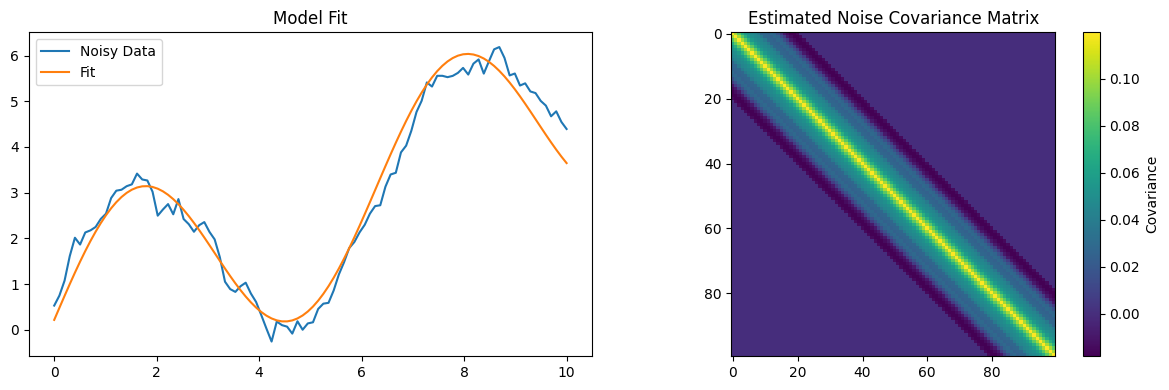

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz

# Simulate time and signal
np.random.seed(0)
N = 100
t = np.linspace(0, 10, N)
true_signal = 2.0 * np.sin(t) + 0.5 * t  # some signal model

# Simulate correlated noise (AR(1)-like)
rho = 0.8  # correlation between time steps
sigma = 0.3
noise = np.zeros(N)
noise[0] = np.random.normal(0, sigma)
for i in range(1, N):
    noise[i] = rho * noise[i-1] + np.random.normal(0, sigma * np.sqrt(1 - rho**2))

# Combine signal and noise
y = true_signal + noise

# STEP 1: Fit a model (simple least squares fit to a sine + linear model)
from scipy.optimize import curve_fit

def model(t, a, b, c):
    return a * np.sin(t) + b * t + c

params, _ = curve_fit(model, t, y)
y_fit = model(t, *params)

# STEP 2: Compute residuals
residuals = y - y_fit

# STEP 3A: Estimate i.i.d. noise (simple variance)
sigma_est = np.var(residuals, ddof=1)
R_iid = sigma_est * np.eye(N)

# STEP 3B: Estimate autocovariance function
def autocovariance(x, max_lag):
    n = len(x)
    x = x - np.mean(x)
    acov = np.array([
        np.sum(x[:n - lag] * x[lag:]) / (n - lag)
        for lag in range(max_lag + 1)
    ])
    return acov

max_lag = 20
acov = autocovariance(residuals, max_lag)

# STEP 4: Build full covariance matrix (Toeplitz)
R_full = toeplitz(acov, acov)

# Optional: Pad to full size if max_lag < N
R_estimated = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        lag = abs(i - j)
        if lag <= max_lag:
            R_estimated[i, j] = acov[lag]

# Visualize results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(t, y, label='Noisy Data')
plt.plot(t, y_fit, label='Fit')
plt.legend()
plt.title("Model Fit")

plt.subplot(1, 2, 2)
plt.imshow(R_estimated, cmap='viridis')
plt.title("Estimated Noise Covariance Matrix")
plt.colorbar(label='Covariance')
plt.tight_layout()
plt.show()
